# Performance Prediction Model

### How to add more features: 
To add more features, the following lines must be changed:
- dtype = np.dtype([...]): for each added feature, add ('feature name', datatype)
- data = np.loadtxt(...): usecols=(...) determines what columns (0-indexed) are used for training. Add the column number of the recently-added feature to the end of the list
- emotion_fields = [...]: add 'feature name' to the list

Class distribution in full dataset:
  Class 0: 208 samples (34.9%)
  Class 1: 188 samples (31.5%)
  Class 2: 200 samples (33.6%)

Class 0 threshold: < 0.85x historical avg
Class 1 threshold: 0.85x - 1.24x historical avg
Class 2 threshold: > 1.24x historical avg

Starting 5-Fold Cross-Validation Training


--- Fold 1/5 ---
Train Accuracy: 0.5273
Validation Accuracy: 0.4333


--- Fold 2/5 ---
Train Accuracy: 0.3333
Validation Accuracy: 0.4118

--- Fold 3/5 ---
Train Accuracy: 0.5178
Validation Accuracy: 0.4790

--- Fold 4/5 ---
Train Accuracy: 0.3606
Validation Accuracy: 0.3613

--- Fold 5/5 ---
Train Accuracy: 0.3082
Validation Accuracy: 0.3950

Cross-Validation Summary
Fold 1: Train=0.5273, Val=0.4333
Fold 2: Train=0.3333, Val=0.4118
Fold 3: Train=0.5178, Val=0.4790
Fold 4: Train=0.3606, Val=0.3613
Fold 5: Train=0.3082, Val=0.3950

Average Train Accuracy: 0.4094
Average Validation Accuracy: 0.4161 (±0.0393)


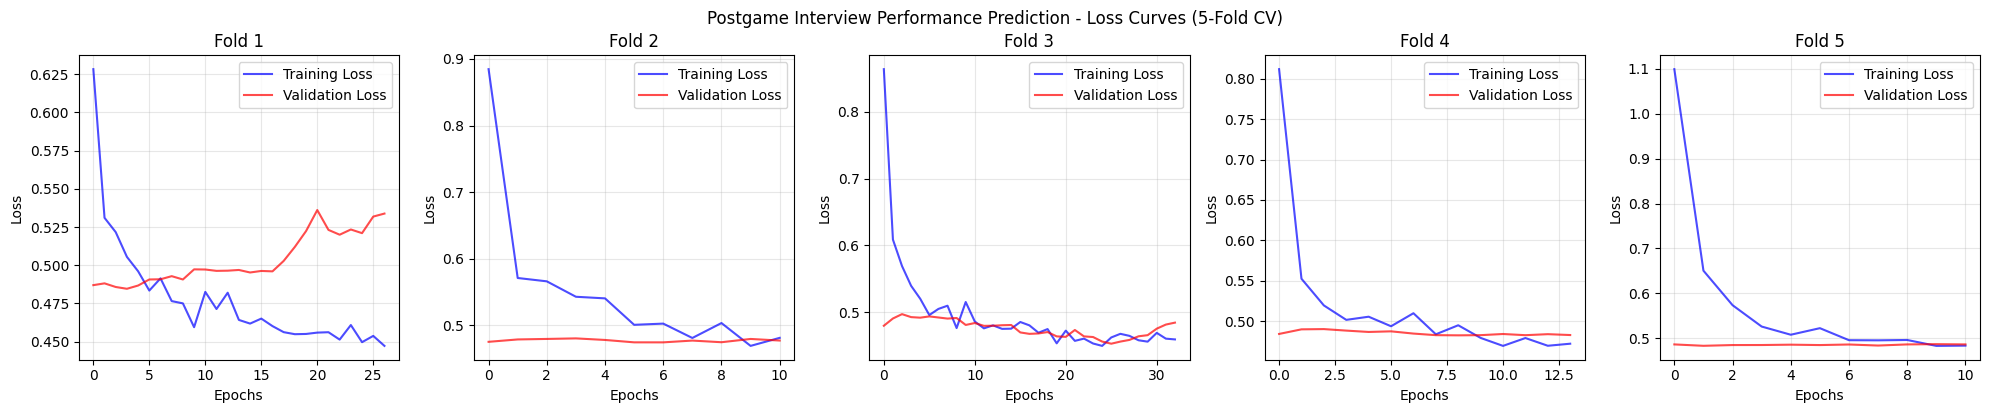

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import KFold
import tensorflow as tf

data_file = 'emotion_results_final_with_gmsc.csv'
dtype = np.dtype([('id', 'U10'), ('avg_angry', float), ('avg_disgust', float), ('avg_fear', float), ('avg_happy', float), ('avg_sad', float), ('avg_surprise', float), ('avg_neutral', float), ('days_of_rest', float), ('opp_drtg', float), ('opp_win_pct', float), ('historical_gmsc_avg', float), ('next_game_gmsc', float)])
data = np.loadtxt(data_file, dtype=dtype, delimiter=',', skiprows=1, usecols=(2, 4, 5, 6, 7, 8, 9, 10, 13, 15, 16, 17, 18))

# perform data normalization (scaling for emotions)
emotion_fields = [
    'avg_angry',
    'avg_disgust',
    'avg_fear',
    'avg_happy',
    'avg_sad',
    'avg_surprise',
    'avg_neutral',
]
for field in emotion_fields:
    data[field] = data[field] / 100.0
    
# scaling for days_of_rest using upper quartile (avoids distortion from outliers)
data['days_of_rest'] = data['days_of_rest'] / np.percentile(data['days_of_rest'], 75)

# standardize opp_drtg
data['opp_drtg'] = (data['opp_drtg'] - np.mean(data['opp_drtg'])) / np.std(data['opp_drtg'])

# even split next_game_gmsc into 3 classes
data['next_game_gmsc'] = np.where(
    data['next_game_gmsc'] < 0.85 * data['historical_gmsc_avg'], 0, 
    np.where(
        data['next_game_gmsc'] <= 1.24 * data['historical_gmsc_avg'], 1, 
        2
    )
)

# standardize historical_gmsc_avg
data['historical_gmsc_avg'] = (data['historical_gmsc_avg'] - np.mean(data['historical_gmsc_avg'])) / np.std(data['historical_gmsc_avg'])

# write data to new csv file for testing
np.savetxt('test_data.csv', data, delimiter=',', fmt='%s', header=','.join(data.dtype.names), comments='')

# Check class distribution
unique, counts = np.unique(data['next_game_gmsc'].astype(int), return_counts=True)
print("Class distribution in full dataset:")
for cls, count in zip(unique, counts):
    print(f"  Class {int(cls)}: {count} samples ({100*count/len(data):.1f}%)")

print(f"\nClass 0 threshold: < {0.85:.2f}x historical avg")
print(f"Class 1 threshold: {0.85:.2f}x - {1.24:.2f}x historical avg")
print(f"Class 2 threshold: > {1.24:.2f}x historical avg")

# Prepare features and labels
feature_names = data.dtype.names[1:-1]
x = np.array([data[name] for name in feature_names]).T
y = np.array(data['next_game_gmsc'])

# 5-Fold Cross-Validation setup
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
fold_num = 0
fold_histories = []
fold_cms_test = []
fold_cms_train = []
fold_accuracies = []

class_weights = [1.0, 1.0, 1.0]

def make_weighted_focal_loss(class_weights, gamma=2.0):
    class_weights_tensor = tf.constant(class_weights, dtype=tf.float32)

    def weighted_focal_loss(y_true, y_pred):
        # y_true is already one-hot encoded
        y_true_one_hot = tf.cast(y_true, tf.float32)

        # Prevent log(0)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # Cross-entropy on probabilities
        ce = -tf.reduce_sum(y_true_one_hot * tf.math.log(y_pred), axis=-1)

        # Probability assigned to the true class
        p_t = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1)

        # Weight for the true class
        alpha_t = tf.reduce_sum(y_true_one_hot * class_weights_tensor, axis=-1)

        focal = alpha_t * tf.pow(1.0 - p_t, gamma) * ce
        return tf.reduce_mean(focal)

    return weighted_focal_loss

loss_fn = make_weighted_focal_loss(class_weights, gamma=2.0)

print("\n" + "="*60)
print("Starting 5-Fold Cross-Validation Training")
print("="*60 + "\n")

for train_idx, val_idx in kfold.split(x):
    fold_num += 1
    print(f"\n--- Fold {fold_num}/5 ---")
    
    # Split data for this fold
    x_train, x_val = x[train_idx], x[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    # Convert to one-hot encoding
    y_train_cat = tf.keras.utils.to_categorical(y_train, 3)
    y_val_cat = tf.keras.utils.to_categorical(y_val, 3)
    
    # Create model
    model = keras.Sequential([
        layers.Input(shape=(x_train.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=loss_fn,
        metrics=['accuracy']
    )
    
    # Train model
    history = model.fit(
        x_train, 
        y_train_cat,
        epochs=100,
        batch_size=16,
        validation_data=(x_val, y_val_cat),
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)],
        verbose=0
    )
    
    fold_histories.append(history)
    
    # Evaluate on validation fold
    val_probs = model.predict(x_val, verbose=0)
    val_pred = np.argmax(val_probs, axis=1)
    val_true = np.argmax(y_val_cat, axis=1)
    val_accuracy = np.mean(val_pred == val_true)
    
    # Evaluate on training fold
    train_probs = model.predict(x_train, verbose=0)
    train_pred = np.argmax(train_probs, axis=1)
    train_true = np.argmax(y_train_cat, axis=1)
    train_accuracy = np.mean(train_pred == train_true)
    
    # Confusion matrices
    cm_val = tf.math.confusion_matrix(val_true, val_pred, num_classes=3).numpy()
    cm_train = tf.math.confusion_matrix(train_true, train_pred, num_classes=3).numpy()
    
    fold_cms_test.append(cm_val)
    fold_cms_train.append(cm_train)
    fold_accuracies.append({'fold': fold_num, 'train': train_accuracy, 'val': val_accuracy})
    
    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    
    keras.backend.clear_session()

print("\n" + "="*60)
print("Cross-Validation Summary")
print("="*60)
for acc in fold_accuracies:
    print(f"Fold {acc['fold']}: Train={acc['train']:.4f}, Val={acc['val']:.4f}")

avg_train_acc = np.mean([acc['train'] for acc in fold_accuracies])
avg_val_acc = np.mean([acc['val'] for acc in fold_accuracies])
std_val_acc = np.std([acc['val'] for acc in fold_accuracies])

print(f"\nAverage Train Accuracy: {avg_train_acc:.4f}")
print(f"Average Validation Accuracy: {avg_val_acc:.4f} (±{std_val_acc:.4f})")
print("="*60)

# Plot loss curves for all folds
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, history in enumerate(fold_histories):
    axes[i].plot(history.history["loss"], "b-", label="Training Loss", alpha=0.7)
    axes[i].plot(history.history["val_loss"], "r-", label="Validation Loss", alpha=0.7)
    axes[i].set_title(f'Fold {i+1}')
    axes[i].set_xlabel("Epochs")
    axes[i].set_ylabel("Loss")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle("Postgame Interview Performance Prediction - Loss Curves (5-Fold CV)", y=1.02)
plt.show()


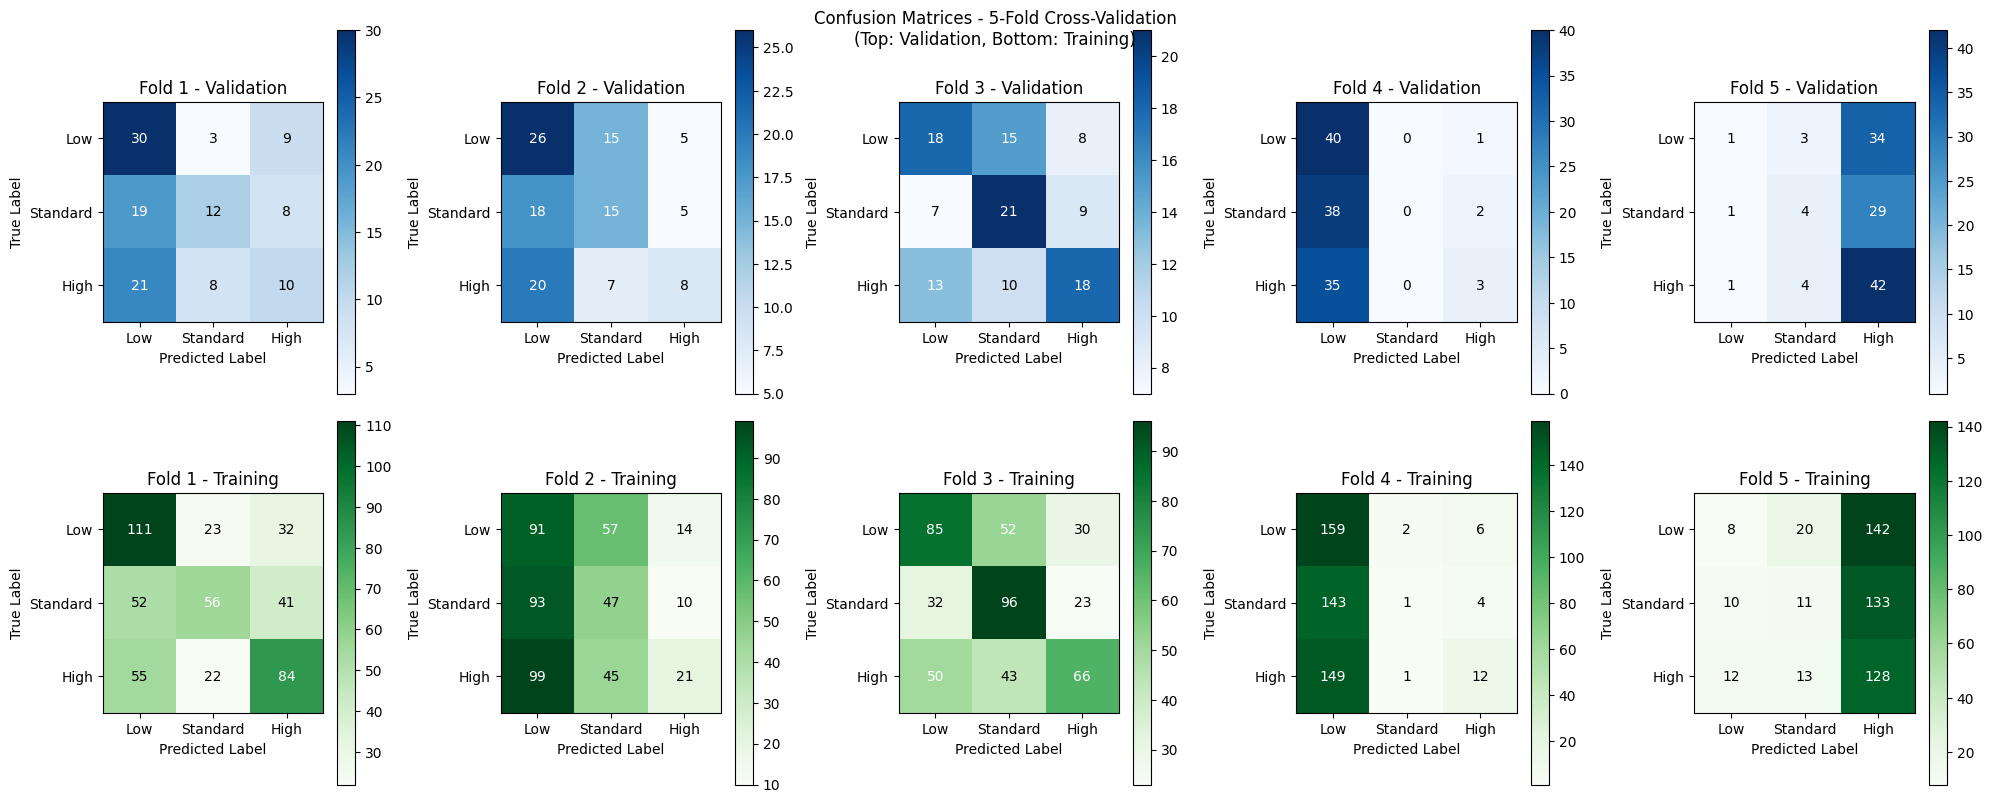

In [2]:
# Display validation confusion matrices for all folds
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
class_labels = ['Low', 'Standard', 'High']

# Validation matrices (top row)
for fold_idx, cm in enumerate(fold_cms_test):
    ax = axes[0, fold_idx]
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(f'Fold {fold_idx+1} - Validation')
    plt.colorbar(im, ax=ax)
    tick_marks = np.arange(len(class_labels))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(class_labels)
    ax.set_yticklabels(class_labels)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    
    # Add text annotations
    threshold = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i,
                format(cm[i, j], 'd'),
                ha='center',
                va='center',
                color='white' if cm[i, j] > threshold else 'black',
            )

# Training matrices (bottom row)
for fold_idx, cm in enumerate(fold_cms_train):
    ax = axes[1, fold_idx]
    im = ax.imshow(cm, interpolation='nearest', cmap='Greens')
    ax.set_title(f'Fold {fold_idx+1} - Training')
    plt.colorbar(im, ax=ax)
    tick_marks = np.arange(len(class_labels))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(class_labels)
    ax.set_yticklabels(class_labels)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    
    # Add text annotations
    threshold = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i,
                format(cm[i, j], 'd'),
                ha='center',
                va='center',
                color='white' if cm[i, j] > threshold else 'black',
            )

plt.tight_layout()
plt.suptitle("Confusion Matrices - 5-Fold Cross-Validation\n(Top: Validation, Bottom: Training)", y=1.00)
plt.show()